<div style="background: linear-gradient(135deg, #ff6b35 0%, #7b2d8b 100%); padding: 36px 32px; border-radius: 16px; margin-bottom: 24px; box-shadow: 0 6px 24px rgba(0,0,0,0.18);">
  <h1 style="color: white; font-size: 2.4em; margin: 0 0 8px 0; letter-spacing: 1px;">🎯 PYNQ 301: Object Detection</h1>
  <p style="color: rgba(255,255,255,0.9); font-size: 1.15em; margin: 0 0 20px 0;">Real-time AI on the KRIA KV260 — powered by YOLOv3 &amp; the DPU</p>
  <div style="display: flex; gap: 12px; flex-wrap: wrap;">
    <span style="background: rgba(255,255,255,0.2); color: white; padding: 6px 14px; border-radius: 20px; font-size: 0.9em;">🧠 Deep Learning</span>
    <span style="background: rgba(255,255,255,0.2); color: white; padding: 6px 14px; border-radius: 20px; font-size: 0.9em;">📷 Computer Vision</span>
    <span style="background: rgba(255,255,255,0.2); color: white; padding: 6px 14px; border-radius: 20px; font-size: 0.9em;">⚡ FPGA Acceleration</span>
    <span style="background: rgba(255,255,255,0.2); color: white; padding: 6px 14px; border-radius: 20px; font-size: 0.9em;">🎮 Interactive</span>
  </div>
</div>

<div style="background: #f3e5f5; border-left: 6px solid #7b2d8b; border-radius: 8px; padding: 20px 24px; margin-bottom: 20px;">
<strong style="color: #4a148c; font-size: 1.05em;">📋 In this notebook you will:</strong>
<ul style="color: #4a148c; margin: 10px 0 0 0; line-height: 1.8;">
<li>Understand what object detection is and how it has evolved over time</li>
<li>Use the YOLOv3 model to detect objects in images and a live webcam feed</li>
<li>Interactively explore how confidence thresholds and class filtering affect results</li>
<li>Display live detection results on an OLED display</li>
</ul>
</div>

---

<div style="border-radius: 10px; overflow: hidden; box-shadow: 0 2px 12px rgba(0,0,0,0.1); margin-bottom: 16px;">
<div style="background: #0097a7; padding: 12px 20px;">
<strong style="color: white; font-size: 1.1em;">📖 Useful Term Cheat Sheet</strong>
</div>
<table style="width: 100%; border-collapse: collapse; font-size: 0.95em;">
<tr style="background: #e0f7fa;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7; width: 160px;">DPU</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">Data Processing Unit — specialized hardware on the FPGA for running AI models fast</td>
</tr>
<tr style="background: #f9fbe7;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7;">YOLO</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">"You Only Look Once" — the object detection algorithm used in this notebook</td>
</tr>
<tr style="background: #e0f7fa;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7;">Overlay</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">A pre-built design loaded onto the FPGA to give it a specific capability</td>
</tr>
<tr style="background: #f9fbe7;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7;">FPGA</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">Field Programmable Gate Array — a chip we can reprogram to do many tasks efficiently</td>
</tr>
<tr style="background: #e0f7fa;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7;">Anchor Box</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">A pre-defined box shape the model uses as a starting guess for where objects are</td>
</tr>
<tr style="background: #f9fbe7;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7;">Bounding Box</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">The rectangle drawn around a detected object in the image</td>
</tr>
<tr style="background: #e0f7fa;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7;">Confidence Score</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">A number from 0 to 1 showing how certain the model is about a detection</td>
</tr>
<tr style="background: #f9fbe7;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7;">NMS</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">Non-Maximum Suppression — removes duplicate overlapping boxes, keeping only the best</td>
</tr>
<tr style="background: #e0f7fa;">
  <td style="padding: 10px 16px; font-weight: bold; color: white; background: #0097a7;">VOC</td>
  <td style="padding: 10px 16px; color: #333;">Visual Object Classes — the dataset YOLOv3 was trained on (20 object categories)</td>
</tr>
</table>
</div>

<div style="background: #e0f7fa; border-left: 6px solid #0097a7; border-radius: 8px; padding: 20px 24px; margin-bottom: 20px;">
<h2 style="color: #006064; margin-top: 0;">🔍 How Does Object Detection Work?</h2>

Object detection answers <strong>two questions at once</strong>:
<ol style="color: #333; line-height: 1.9;">
<li><strong>What</strong> is in the image? (classification)</li>
<li><strong>Where</strong> is it? (localization — drawing a bounding box)</li>
</ol>

Early approaches like <em>R-CNN (2014)</em> ran a classifier on hundreds of separate image patches — accurate but very slow. <strong>YOLO changed everything in 2016</strong> by doing it all in a single pass through the network.
</div>

<div style="border-radius: 10px; overflow: hidden; box-shadow: 0 2px 12px rgba(0,0,0,0.1); margin-bottom: 20px;">
<div style="background: #0097a7; padding: 12px 20px;">
<strong style="color: white; font-size: 1.05em;">🚀 The YOLO Family — How It Has Evolved</strong>
</div>
<table style="width: 100%; border-collapse: collapse; font-size: 0.95em;">
<tr style="background: #e0f7fa;">
  <td style="padding: 10px 16px; font-weight: bold; color: #006064; border-bottom: 1px solid #b2dfdb; width: 70px;">2016</td>
  <td style="padding: 10px 16px; font-weight: bold; color: #006064; border-bottom: 1px solid #b2dfdb; width: 100px;">YOLOv1</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">First single-pass detector — fast but lower accuracy</td>
</tr>
<tr style="background: #fff8e1; border-left: 4px solid #f9a825;">
  <td style="padding: 10px 16px; font-weight: bold; color: #e65100; border-bottom: 1px solid #ffe082;">2018</td>
  <td style="padding: 10px 16px; font-weight: bold; color: #e65100; border-bottom: 1px solid #ffe082;">YOLOv3 ⭐</td>
  <td style="padding: 10px 16px; color: #5d4037; border-bottom: 1px solid #ffe082;"><strong>Multi-scale detection using 3 grids — what we use today!</strong></td>
</tr>
<tr style="background: #e0f7fa;">
  <td style="padding: 10px 16px; font-weight: bold; color: #006064; border-bottom: 1px solid #b2dfdb;">2020</td>
  <td style="padding: 10px 16px; font-weight: bold; color: #006064; border-bottom: 1px solid #b2dfdb;">YOLOv5</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">Easier training, better accuracy, Python-native</td>
</tr>
<tr style="background: #f9fbe7;">
  <td style="padding: 10px 16px; font-weight: bold; color: #006064; border-bottom: 1px solid #b2dfdb;">2022</td>
  <td style="padding: 10px 16px; font-weight: bold; color: #006064; border-bottom: 1px solid #b2dfdb;">YOLOv8</td>
  <td style="padding: 10px 16px; color: #333; border-bottom: 1px solid #b2dfdb;">Anchor-free detection heads, state-of-the-art speed/accuracy</td>
</tr>
<tr style="background: #e0f7fa;">
  <td style="padding: 10px 16px; font-weight: bold; color: #006064;">2023</td>
  <td style="padding: 10px 16px; font-weight: bold; color: #006064;">RT-DETR</td>
  <td style="padding: 10px 16px; color: #333;">Transformer-based real-time detector — no anchor boxes at all</td>
</tr>
</table>
</div>

<div style="background: #ede7f6; border-left: 6px solid #7b1fa2; border-radius: 8px; padding: 18px 22px; margin-bottom: 20px;">
<strong style="color: #4a148c;">💡 How Do Anchor Boxes Work?</strong><br><br>
<span style="color: #4a148c;">Think of anchor boxes like a <strong>fishing net with holes of different sizes and shapes</strong>. Before the model even looks at the image, it lays this net over a grid. Each "hole" is a pre-defined box shape (tall, wide, square…). The model then asks: <em>"For each grid cell and each anchor shape, is there an object here, and how much do I need to resize the anchor to fit it?"</em><br><br>
YOLOv3 uses <strong>9 anchor shapes</strong> across 3 grid scales: <strong>13×13</strong> for big objects · <strong>26×26</strong> for medium · <strong>52×52</strong> for small.</span>
</div>

<div style="background: #e0f7fa; border-left: 6px solid #0097a7; border-radius: 8px; padding: 18px 22px; margin-bottom: 12px;">
<strong style="color: #006064;">🗂️ What is VOC?</strong><br><br>
<span style="color: #006064;">VOC is a dataset from the <strong>PASCAL Visual Object Classes Challenge</strong>. It contains 11,540 images with 27,450 annotated objects across <strong>20 categories</strong>.</span>
</div>

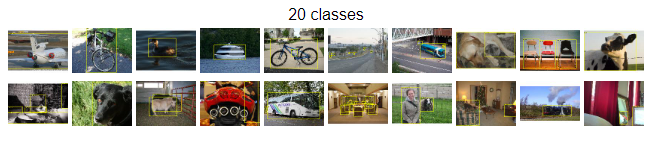
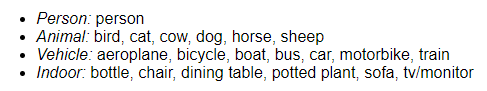

# Hardware Setup
----
### 1. KRIA KV260 Board<br> 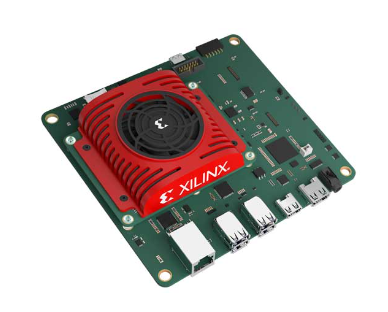
### 2. PYNQ Grove Adapter<br> 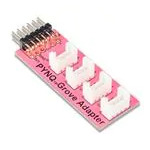
### 3. OLED Display<br> 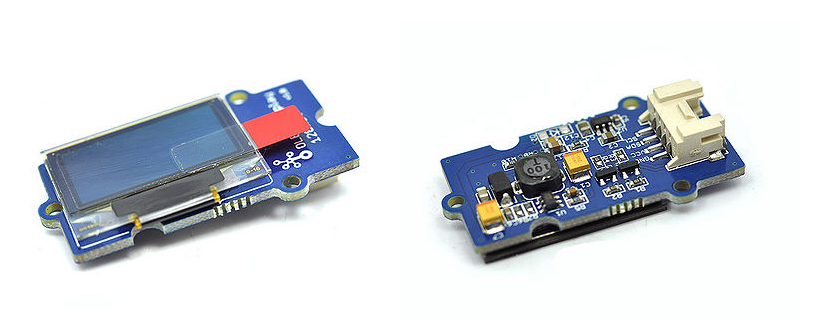
### 4. Webcam<br>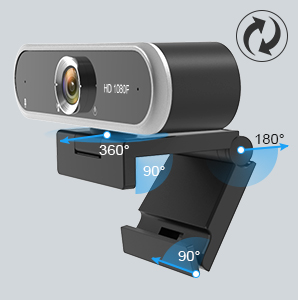

# Let's get started 
----

<div style="background: linear-gradient(90deg, #0097a7 0%, #00bcd4 100%); border-radius: 10px; padding: 16px 24px; margin: 8px 0 16px 0; box-shadow: 0 3px 10px rgba(0,151,167,0.3);">
<h2 style="color: white; margin: 0; font-size: 1.4em;">⚙️ Step 1 — Prepare the Overlay</h2>
<p style="color: rgba(255,255,255,0.85); margin: 4px 0 0 0; font-size: 0.95em;">Load the DPU design onto the FPGA and connect the OLED display</p>
</div>

In [ ]:
from pynq_dpu import DpuOverlay
from pynq_peripherals import PmodGroveAdapter
overlay = DpuOverlay("dpu.bit")

In [ ]:
# Initiate pmod adapter. G4 indicates that the OLED is connected to the G4 slot on the PYNQ Grove Adapter
adapter = PmodGroveAdapter(overlay.PMODA, G4='grove_oled')
oled = adapter.G4
oled.set_default_config()
oled.set_normal_display()


<div style="background: linear-gradient(90deg, #0097a7 0%, #00bcd4 100%); border-radius: 10px; padding: 16px 24px; margin: 8px 0 16px 0; box-shadow: 0 3px 10px rgba(0,151,167,0.3);">
<h2 style="color: white; margin: 0; font-size: 1.4em;">🛠️ Step 2 — Import Libraries &amp; Define Utility Functions</h2>
<p style="color: rgba(255,255,255,0.85); margin: 4px 0 0 0; font-size: 0.95em;">Set up the pre-processing pipeline, bounding box decoder, and drawing helpers</p>
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>📦 What gets imported (click to see)</strong> &nbsp;— click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image
from yolo_helpers import (
    load_classes, make_colors, load_anchors,
    setup_dpu_buffers, list_images,
    pre_process, evaluate, draw_boxes
)
%matplotlib inline</code></pre></div>
</details>

In [ ]:
from pathlib import Path
import subprocess, sys, importlib

try:
    import bootcamp_utils.live_detection
except ImportError:
    repo_root = next(p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / "setup.py").exists())
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "--upgrade", "--no-build-isolation", str(repo_root)])
    importlib.invalidate_caches()

import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from IPython.display import display, Image
from bootcamp_utils.color_utils import load_classes, make_colors
from bootcamp_utils.dpu_utils import setup_dpu_buffers, list_images
from bootcamp_utils.live_detection import launch_live_detection
from yolo_helpers import load_anchors, pre_process, evaluate, draw_boxes
%matplotlib inline


<div style="background: #e0f7fa; border-left: 4px solid #0097a7; border-radius: 6px; padding: 10px 16px; color: #006064;">
Now we'll load the <strong>YOLOv3 xmodel</strong> trained on the VOC dataset onto the DPU.
</div>

In [ ]:
overlay.load_model("tf_yolov3_voc.xmodel")

<div style="background: #ede7f6; border-left: 4px solid #7b1fa2; border-radius: 6px; padding: 10px 16px; color: #4a148c;">
YOLOv3 uses <strong>9 anchor box shapes</strong> — pre-defined width/height pairs the model was trained with. The helper loads them for you. Expand the toggle below if you want to see the values.
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🔍 yolo_helpers.py — click to see function signatures</strong></summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;"><code>def load_anchors() -> np.ndarray
def pre_process(image, model_image_size) -> np.ndarray
def evaluate(yolo_outputs, image_shape, class_names, anchors, score_thresh=0.2)
def draw_boxes(image, boxes, scores, classes, class_names, colors) -> Axes
def run(frame, dpu, input_data, output_data, image_buf, shapeIn,
        shapeOut0, shapeOut1, shapeOut2, class_names, anchors, colors, display=False)</code></pre></div>
</details>


In [ ]:
anchors = load_anchors()

<div style="background: #e0f7fa; border-left: 4px solid #0097a7; border-radius: 6px; padding: 10px 16px; color: #006064;">
The VOC dataset has <strong>20 detectable classes</strong> (person, dog, car, bicycle…). <code>load_classes()</code> reads them from <code>img/voc_classes.txt</code>. Each class is automatically assigned a unique color for its bounding box.
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>📋 load_classes() — reads the 20 VOC class names from a text file</strong> &nbsp;— click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>def load_classes(classes_path):
    with open(classes_path) as f:
        class_names = [c.strip() for c in f.readlines()]
    return class_names</code></pre></div>
</details>

In [ ]:
class_names = load_classes('img/voc_classes.txt')

<div style="background: #ede7f6; border-left: 4px solid #7b1fa2; border-radius: 6px; padding: 10px 16px; color: #4a148c;">
<code>make_colors()</code> generates a unique color for each of the 20 classes so bounding boxes are easy to tell apart at a glance. The color list is stored in <code>colors</code> and used by <code>draw_boxes()</code> inside <code>yolo_helpers.py</code>.
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🎨 make_colors() — assigns a unique color to every class</strong> &nbsp;— click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>def make_colors(class_names):
    n = len(class_names)
    hsv_tuples = [(1.0 * x / n, 1., 1.) for x in range(n)]
    colors = list(map(lambda x: colorsys.hsv_to_rgb(*x), hsv_tuples))
    colors = list(map(lambda x: (int(x[0]*255), int(x[1]*255), int(x[2]*255)), colors))
    random.seed(0)
    random.shuffle(colors)  # reproducible but shuffled so nearby classes look different
    random.seed(None)
    return colors</code></pre></div>
</details>

In [ ]:
colors = make_colors(class_names)

<div style="background: #e0f7fa; border-left: 4px solid #0097a7; border-radius: 6px; padding: 10px 16px; color: #006064;">
All the heavy lifting — image resizing, anchor decoding, NMS box filtering, and drawing — lives in <code>yolo_helpers.py</code>. You do not need to touch that file. The <code>run()</code> function below calls everything automatically.
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🔬 Full helper code — pre-processing, NMS, draw_boxes (yolo_helpers.py)</strong> &nbsp;— click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>&quot;&quot;&quot;
YOLOv3 helper functions — pre-processing, decoding, NMS, drawing, and setup.
Students don&#x27;t need to read or edit this file.
&quot;&quot;&quot;
import os
import time
import random
import colorsys

import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Image


# ---------------------------------------------------------------------------
# Class names &amp; colors
# ---------------------------------------------------------------------------

def load_classes(classes_path=&quot;img/voc_classes.txt&quot;):
    with open(classes_path) as f:
        class_names = [c.strip() for c in f.readlines()]
    return class_names


def make_colors(class_names):
    n = len(class_names)
    hsv_tuples = [(1.0 * x / n, 1., 1.) for x in range(n)]
    colors = list(map(lambda x: colorsys.hsv_to_rgb(*x), hsv_tuples))
    colors = list(map(lambda x: (int(x[0]*255), int(x[1]*255), int(x[2]*255)), colors))
    random.seed(0)
    random.shuffle(colors)
    random.seed(None)
    return colors


# ---------------------------------------------------------------------------
# Anchor boxes (YOLOv3 VOC defaults)
# ---------------------------------------------------------------------------

def load_anchors():
    anchor_list = [10,13,16,30,33,23,30,61,62,45,59,119,116,90,156,198,373,326]
    return np.array([float(x) for x in anchor_list]).reshape(-1, 2)


# ---------------------------------------------------------------------------
# DPU tensor setup
# ---------------------------------------------------------------------------

def setup_dpu_buffers(overlay):
    &quot;&quot;&quot;Return (dpu, input_data, output_data, image_buf, shape_in, shape_outs).&quot;&quot;&quot;
    dpu = overlay.runner
    inputTensors  = dpu.get_input_tensors()
    outputTensors = dpu.get_output_tensors()

    shapeIn   = tuple(inputTensors[0].dims)
    shapeOut0 = tuple(outputTensors[0].dims)
    shapeOut1 = tuple(outputTensors[1].dims)
    shapeOut2 = tuple(outputTensors[2].dims)

    input_data  = [np.empty(shapeIn,   dtype=np.float32, order=&quot;C&quot;)]
    output_data = [np.empty(shapeOut0, dtype=np.float32, order=&quot;C&quot;),
                   np.empty(shapeOut1, dtype=np.float32, order=&quot;C&quot;),
                   np.empty(shapeOut2, dtype=np.float32, order=&quot;C&quot;)]

    return dpu, input_data, output_data, input_data[0], shapeIn, (shapeOut0, shapeOut1, shapeOut2)


def list_images(image_folder=&quot;img&quot;):
    images = [i for i in os.listdir(image_folder) if i.endswith(&quot;JPEG&quot;)]
    return image_folder, images


# ---------------------------------------------------------------------------
# Pre-processing
# ---------------------------------------------------------------------------

def letterbox_image(image, size):
    ih, iw, _ = image.shape
    w, h = size
    scale = min(w/iw, h/ih)
    nw, nh = int(iw*scale), int(ih*scale)
    image = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
    new_image = np.ones((h, w, 3), np.uint8) * 128
    h_start, w_start = (h-nh)//2, (w-nw)//2
    new_image[h_start:h_start+nh, w_start:w_start+nw, :] = image
    return new_image


def pre_process(image, model_image_size):
    image = image[...,::-1]
    image_h, image_w, _ = image.shape
    if model_image_size != (None, None):
        assert model_image_size[0] % 32 == 0, &#x27;Multiples of 32 required&#x27;
        assert model_image_size[1] % 32 == 0, &#x27;Multiples of 32 required&#x27;
        boxed_image = letterbox_image(image, tuple(reversed(model_image_size)))
    else:
        new_image_size = (image_w - (image_w % 32), image_h - (image_h % 32))
        boxed_image = letterbox_image(image, new_image_size)
    image_data = np.array(boxed_image, dtype=&#x27;float32&#x27;) / 255.
    return np.expand_dims(image_data, 0)


# ---------------------------------------------------------------------------
# Decoding / NMS
# ---------------------------------------------------------------------------

def _get_feats(feats, anchors, num_classes, input_shape):
    num_anchors = len(anchors)
    anchors_tensor = np.reshape(np.array(anchors, dtype=np.float32), [1,1,1,num_anchors,2])
    grid_size = np.shape(feats)[1:3]
    nu = num_classes + 5
    predictions = np.reshape(feats, [-1, grid_size[0], grid_size[1], num_anchors, nu])
    grid_y = np.tile(np.reshape(np.arange(grid_size[0]), [-1,1,1,1]), [1,grid_size[1],1,1])
    grid_x = np.tile(np.reshape(np.arange(grid_size[1]), [1,-1,1,1]), [grid_size[0],1,1,1])
    grid = np.array(np.concatenate([grid_x, grid_y], axis=-1), dtype=np.float32)
    box_xy = (1/(1+np.exp(-predictions[...,:2])) + grid) / np.array(grid_size[::-1], dtype=np.float32)
    box_wh = np.exp(predictions[...,2:4]) * anchors_tensor / np.array(input_shape[::-1], dtype=np.float32)
    box_confidence  = 1/(1+np.exp(-predictions[...,4:5]))
    box_class_probs = 1/(1+np.exp(-predictions[...,5:]))
    return box_xy, box_wh, box_confidence, box_class_probs


def correct_boxes(box_xy, box_wh, input_shape, image_shape):
    box_yx = box_xy[...,::-1]
    box_hw = box_wh[...,::-1]
    input_shape = np.array(input_shape, dtype=np.float32)
    image_shape = np.array(image_shape, dtype=np.float32)
    new_shape = np.around(image_shape * np.min(input_shape/image_shape))
    offset = (input_shape - new_shape) / 2. / input_shape
    scale  = input_shape / new_shape
    box_yx = (box_yx - offset) * scale
    box_hw *= scale
    box_mins  = box_yx - (box_hw/2.)
    box_maxes = box_yx + (box_hw/2.)
    boxes = np.concatenate([box_mins[...,0:1], box_mins[...,1:2],
                            box_maxes[...,0:1], box_maxes[...,1:2]], axis=-1)
    boxes *= np.concatenate([image_shape, image_shape], axis=-1)
    return boxes


def boxes_and_scores(feats, anchors, classes_num, input_shape, image_shape):
    box_xy, box_wh, box_confidence, box_class_probs = _get_feats(feats, anchors, classes_num, input_shape)
    boxes = np.reshape(correct_boxes(box_xy, box_wh, input_shape, image_shape), [-1, 4])
    box_scores = np.reshape(box_confidence * box_class_probs, [-1, classes_num])
    return boxes, box_scores


def nms_boxes(boxes, scores):
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    areas = (x2-x1+1)*(y2-y1+1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size &gt; 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w1 = np.maximum(0.0, xx2-xx1+1)
        h1 = np.maximum(0.0, yy2-yy1+1)
        inter = w1*h1
        ovr   = inter / (areas[i] + areas[order[1:]] - inter)
        order = order[np.where(ovr &lt;= 0.55)[0]+1]
    return keep


def evaluate(yolo_outputs, image_shape, class_names, anchors, score_thresh=0.2):
    anchor_mask = [[6,7,8],[3,4,5],[0,1,2]]
    input_shape = np.array(np.shape(yolo_outputs[0])[1:3]) * 32
    boxes, box_scores = [], []
    for i in range(len(yolo_outputs)):
        b, s = boxes_and_scores(yolo_outputs[i], anchors[anchor_mask[i]],
                                len(class_names), input_shape, image_shape)
        boxes.append(b); box_scores.append(s)
    boxes      = np.concatenate(boxes,      axis=0)
    box_scores = np.concatenate(box_scores, axis=0)
    mask = box_scores &gt;= score_thresh
    boxes_, scores_, classes_ = [], [], []
    for c in range(len(class_names)):
        cb = boxes[mask[:,c]]
        cs = box_scores[:,c][mask[:,c]]
        if len(cs) == 0:
            continue
        idx = nms_boxes(cb, cs)
        boxes_.append(cb[idx])
        scores_.append(cs[idx])
        classes_.append(np.ones_like(cs[idx], dtype=np.int32) * c)
    if not boxes_:
        return np.array([]), np.array([]), np.array([], dtype=np.int32)
    return (np.concatenate(boxes_),
            np.concatenate(scores_),
            np.concatenate(classes_))


# ---------------------------------------------------------------------------
# Drawing
# ---------------------------------------------------------------------------

def draw_boxes(image, boxes, scores, classes, class_names, colors):
    _, ax = plt.subplots(1)
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for i, bbox in enumerate(boxes):
        top, left, bottom, right = bbox
        width, height = right-left, bottom-top
        score, class_index = scores[i], classes[i]
        label = &#x27;{}: {:.4f}&#x27;.format(class_names[class_index], score)
        color = tuple([c/255 for c in colors[class_index]])
        ax.add_patch(Rectangle((left,top), width, height,
                                edgecolor=color, facecolor=&#x27;none&#x27;))
        ax.annotate(label, (left+width*0.5, top+height*0.5),
                    color=color, weight=&#x27;bold&#x27;, fontsize=12,
                    ha=&#x27;center&#x27;, va=&#x27;center&#x27;)
    return ax</code></pre></div>
</details>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🖼️ list_images() — scans the img/ folder for JPEG files</strong> &nbsp;— click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>def list_images(image_folder):
    images = [i for i in os.listdir(image_folder) if i.endswith(&#x27;JPEG&#x27;)]
    return image_folder, images</code></pre></div>
</details>

In [ ]:
image_folder, original_images = list_images('img')

<div style="background: linear-gradient(90deg, #0097a7 0%, #00bcd4 100%); border-radius: 10px; padding: 16px 24px; margin: 8px 0 16px 0; box-shadow: 0 3px 10px rgba(0,151,167,0.3);">
<h2 style="color: white; margin: 0; font-size: 1.4em;">🖼️ Step 3 — Detect Objects in a Static Image</h2>
<p style="color: rgba(255,255,255,0.85); margin: 4px 0 0 0; font-size: 0.95em;">Run YOLOv3 inference on sample JPEG images from the <code style="background: rgba(255,255,255,0.2); padding: 2px 6px; border-radius: 4px;">img/</code> folder</p>
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🔧 setup_dpu_buffers() — wires up the FPGA input/output memory buffers</strong> &nbsp;— click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>def setup_dpu_buffers(overlay):
    dpu = overlay.runner
    inputTensors  = dpu.get_input_tensors()
    outputTensors = dpu.get_output_tensors()
    shapeIn   = tuple(inputTensors[0].dims)
    shapeOut0 = tuple(outputTensors[0].dims)
    shapeOut1 = tuple(outputTensors[1].dims)
    shapeOut2 = tuple(outputTensors[2].dims)
    input_data  = [np.empty(shapeIn,   dtype=np.float32, order=&#x27;C&#x27;)]
    output_data = [np.empty(shapeOut0, dtype=np.float32, order=&#x27;C&#x27;),
                   np.empty(shapeOut1, dtype=np.float32, order=&#x27;C&#x27;),
                   np.empty(shapeOut2, dtype=np.float32, order=&#x27;C&#x27;)]
    return dpu, input_data, output_data, input_data[0], shapeIn,\
           (shapeOut0, shapeOut1, shapeOut2)</code></pre></div>
</details>

In [ ]:
dpu, input_data, output_data, image, shapeIn, (shapeOut0, shapeOut1, shapeOut2) = setup_dpu_buffers(overlay)
_dpu_state = dict(dpu=dpu, input_data=input_data, output_data=output_data,
                  image=image, shapeIn=shapeIn, shapeOuts=(shapeOut0, shapeOut1, shapeOut2))

<div style="background: #ede7f6; border-left: 6px solid #7b1fa2; border-radius: 8px; padding: 16px 20px; margin: 8px 0;">
<strong style="color: #4a148c;">🧩 The <code style="background: rgba(123,29,138,0.1); padding: 2px 6px; border-radius: 4px;">run()</code> Function — the engine of this notebook</strong><br>
<span style="color: #4a148c; line-height: 1.7;">This is the only function you need to call to detect objects. It handles the full pipeline: pre-process the frame → send to the DPU → retrieve output tensors → decode results using helpers from <code>yolo_helpers.py</code> → return <code>boxes, scores, classes</code>. Expand the toggle above to see inside it.</span>
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🚀 The run() function — curious? peek at the detection pipeline inside</strong> &nbsp;— click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>def run(frame, display=False):
    image_size = frame.shape[:2]
    image_data = np.array(pre_process(frame, (416, 416)), dtype=np.float32)
    image[0,...] = image_data.reshape(shapeIn[1:])
    job_id = dpu.execute_async(input_data, output_data)
    dpu.wait(job_id)
    yolo_outputs = [
        np.reshape(output_data[0], shapeOut0),
        np.reshape(output_data[1], shapeOut1),
        np.reshape(output_data[2], shapeOut2),
    ]
    boxes, scores, classes = evaluate(yolo_outputs, image_size, class_names, anchors)
    if display:
        draw_boxes(frame, boxes, scores, classes, class_names, colors)
    return boxes, scores, classes</code></pre></div>
</details>

In [ ]:
from yolo_helpers import run as _run

def run(frame, display=False):
    return _run(frame, dpu, input_data, output_data, image,
               shapeIn, shapeOut0, shapeOut1, shapeOut2,
               class_names, anchors, colors, display)

In [ ]:
input_image = cv2.imread(str(Path(image_folder) / original_images[4]))


In [ ]:
# Run detection once — reuse results in the center-point and class explorer cells below
_boxes, _scores, _classes = run(input_image, display=True)


<div style="background:#e0f7fa;border-left:4px solid #0097a7;border-radius:6px;padding:10px 16px;color:#006064;">
Calculate the <strong>center point</strong> of each bounding box. The center is the midpoint between the left/right
and top/bottom edges — useful for tracking, aiming, or triggering actions based on where an object is.
</div>


In [ ]:
# boxes shape: (N, 4) — [top, left, bottom, right]
print(f"{len(_boxes)} object(s) detected")
for i, bbox in enumerate(_boxes):
    top, left, bottom, right = bbox
    cx, cy = (left + right) / 2, (top + bottom) / 2
    print(f"  {class_names[_classes[i]]:15s}  center=({cx:.0f}, {cy:.0f})"  f"  [top={top:.0f} left={left:.0f} bottom={bottom:.0f} right={right:.0f}]")


<div style="background: linear-gradient(90deg, #43a047 0%, #66bb6a 100%); border-radius: 10px; padding: 16px 24px; margin: 8px 0 16px 0; box-shadow: 0 3px 10px rgba(67,160,71,0.3);">
<h2 style="color: white; margin: 0; font-size: 1.4em;">🎮 Step 3.5 — Interactive: Class Explorer</h2>
<p style="color: rgba(255,255,255,0.9); margin: 4px 0 0 0; font-size: 0.95em;">Filter detections by class using a live dropdown — no re-inference needed</p>
</div>

The model just ran detection on the image above. Now let's **explore the results interactively!**

<div style="background: #fff8e1; border-left: 6px solid #f9a825; border-radius: 8px; padding: 16px 20px; margin: 12px 0;">
<strong style="color: #5d4037;">🎤 Presenter Tip</strong><br>
<span style="color: #5d4037; line-height: 1.8;">Ask the class: <em>"What objects do you think the model found in this image? Let's pick one from the dropdown and check!"</em><br>Run the cell, then pick different classes to reveal what the model found — and what it missed.</span>
</div>

<div style="background: #e8f5e9; border-left: 6px solid #43a047; border-radius: 8px; padding: 16px 20px; margin: 12px 0;">
<strong style="color: #1b5e20;">👩‍💻 Students</strong><br>
<span style="color: #1b5e20; line-height: 1.8;">Use the dropdown to select any of the 20 VOC classes. Classes marked with <strong>✅</strong> were detected in this image. Try selecting a class that <em>wasn't</em> detected — what does the model show?</span>
</div>

In [ ]:
from class_explorer import launch_class_explorer

launch_class_explorer(input_image, _boxes, _scores, _classes, class_names, colors)


<div style="background: linear-gradient(90deg, #0097a7 0%, #00bcd4 100%); border-radius: 10px; padding: 16px 24px; margin: 8px 0 16px 0; box-shadow: 0 3px 10px rgba(0,151,167,0.3);">
<h2 style="color: white; margin: 0; font-size: 1.4em;">📷 Step 4 — Single-Frame Webcam Detection</h2>
<p style="color: rgba(255,255,255,0.85); margin: 4px 0 0 0; font-size: 0.95em;">Capture one frame from the webcam and run detection on it</p>
</div>

In [ ]:
# Start capturing a video 
videoIn = cv2.VideoCapture(0)
videoIn.set(cv2.CAP_PROP_BUFFERSIZE, 1)  # Disable buffering
videoIn.set(cv2.CAP_PROP_FRAME_WIDTH, 640);
videoIn.set(cv2.CAP_PROP_FRAME_HEIGHT, 480);

print("Capture device is open: " + str(videoIn.isOpened()))

<div style="background: #fff8e1; border-left: 4px solid #f9a825; border-radius: 6px; padding: 10px 16px; color: #5d4037;">
Run the next cell to <strong>capture a single frame</strong> from the webcam. Then the cell after that runs YOLOv3 detection on it.
</div>

In [ ]:
# Capture a single frame from the webcam
ret, frame = videoIn.read()
if not ret or frame is None:
    print('Camera not ready — run this cell again in a moment.')
else:
    print('Frame captured successfully:', frame.shape)


In [ ]:
# Perform predictions on the frame
boxes, scores, classes = run(frame, display=True)

In [ ]:
# Show the highest-scoring detection (guard against empty results)
if len(scores) > 0:
    best_score = np.argmax(scores)
    print('Top detection:', class_names[classes[best_score]],
          f'({scores[best_score]*100:.0f}%)')
else:
    print('No objects detected in this frame — try re-capturing.')


In [ ]:
# Sort all detections by score descending, then keep the top 2
if len(scores) > 0:
    sorted_idx = np.argsort(scores)[::-1]   # highest score first
    top2 = sorted_idx[:2]
    print("Top 2 detections:")
    for rank, i in enumerate(top2, start=1):
        top, left, bottom, right = boxes[i]
        cx = (left + right) / 2
        cy = (top  + bottom) / 2
        print(f"  #{rank}: {class_names[classes[i]]:15s}  "
              f"confidence={scores[i]*100:.0f}%  "
              f"center=({cx:.0f}, {cy:.0f})")
else:
    print("No objects detected in this frame.")


<div style="background: linear-gradient(90deg, #43a047 0%, #66bb6a 100%); border-radius: 10px; padding: 16px 24px; margin: 8px 0 16px 0; box-shadow: 0 3px 10px rgba(67,160,71,0.3);">
<h2 style="color: white; margin: 0; font-size: 1.4em;">🎚️ Step 4.5 — Interactive: Confidence Threshold Explorer</h2>
<p style="color: rgba(255,255,255,0.9); margin: 4px 0 0 0; font-size: 0.95em;">Drag the slider to see how the detection threshold affects results — in real time</p>
</div>

The model assigns every detection a **confidence score** from 0 to 1. We normally filter out anything below **0.2 (20%)**. But what happens when you move that cutoff?

<div style="display: flex; gap: 16px; margin: 14px 0; flex-wrap: wrap;">
<div style="flex: 1; min-width: 200px; background: #fce4ec; border-left: 5px solid #e91e63; border-radius: 8px; padding: 14px 18px;">
<strong style="color: #880e4f;">⬇️ Lower threshold</strong><br>
<span style="color: #880e4f;">More boxes appear — the model shows its uncertain guesses too</span>
</div>
<div style="flex: 1; min-width: 200px; background: #e8f5e9; border-left: 5px solid #43a047; border-radius: 8px; padding: 14px 18px;">
<strong style="color: #1b5e20;">⬆️ Higher threshold</strong><br>
<span style="color: #1b5e20;">Fewer boxes — only the most confident detections remain</span>
</div>
</div>

<div style="background: #fff8e1; border-left: 6px solid #f9a825; border-radius: 8px; padding: 16px 20px; margin: 12px 0;">
<strong style="color: #5d4037;">🎤 Presenter Tip</strong><br>
<span style="color: #5d4037; line-height: 1.8;"><em>"Who thinks a higher threshold is always better? Let's test it — drag the slider and watch what happens to the boxes!"</em></span>
</div>

<div style="background: #e8f5e9; border-left: 6px solid #43a047; border-radius: 8px; padding: 16px 20px; margin: 12px 0;">
<strong style="color: #1b5e20;">👩‍💻 Student Challenge</strong><br>
<span style="color: #1b5e20; line-height: 1.8;">Find the threshold where only the <strong>most obvious object</strong> in the frame remains. What value did you land on? Compare with a classmate!</span>
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🎚️ Confidence Explorer — full widget code in confidence_explorer.py</strong> &nbsp;— click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>&quot;&quot;&quot;
Confidence Threshold Explorer widget — drag a slider to filter detections.
Students don&#x27;t need to read or edit this file.
&quot;&quot;&quot;
import numpy as np
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display as ipy_display

from yolo_helpers import boxes_and_scores, nms_boxes


def launch_confidence_explorer(frame, dpu_state, class_names, colors, anchors):
    &quot;&quot;&quot;
    Run inference once at a very low threshold, then let students drag a slider
    to see how confidence cutoff affects what gets drawn — no re-inference needed.

    dpu_state must be the dict returned by setup_dpu_buffers(), i.e.:
        {&#x27;dpu&#x27;: dpu, &#x27;input_data&#x27;: input_data, &#x27;output_data&#x27;: output_data,
         &#x27;image&#x27;: image_buf, &#x27;shapeIn&#x27;: shapeIn, &#x27;shapeOuts&#x27;: (s0,s1,s2)}
    &quot;&quot;&quot;
    from yolo_helpers import pre_process

    dpu        = dpu_state[&#x27;dpu&#x27;]
    input_data = dpu_state[&#x27;input_data&#x27;]
    output_data= dpu_state[&#x27;output_data&#x27;]
    image_buf  = dpu_state[&#x27;image&#x27;]
    shapeIn    = dpu_state[&#x27;shapeIn&#x27;]
    shapeOut0, shapeOut1, shapeOut2 = dpu_state[&#x27;shapeOuts&#x27;]

    # --- Run inference once at a very low threshold ---
    image_size = frame.shape[:2]
    image_data = np.array(pre_process(frame, (416, 416)), dtype=np.float32)
    image_buf[0, ...] = image_data.reshape(shapeIn[1:])
    job_id = dpu.execute_async(input_data, output_data)
    dpu.wait(job_id)

    yolo_outputs = [
        np.reshape(output_data[0], shapeOut0),
        np.reshape(output_data[1], shapeOut1),
        np.reshape(output_data[2], shapeOut2),
    ]
    anchor_mask = [[6,7,8],[3,4,5],[0,1,2]]
    input_shape = np.array(np.shape(yolo_outputs[0])[1:3]) * 32
    all_boxes, all_scores = [], []
    for i in range(3):
        b, s = boxes_and_scores(yolo_outputs[i], anchors[anchor_mask[i]],
                                len(class_names), input_shape, image_size)
        all_boxes.append(b); all_scores.append(s)
    raw_boxes  = np.concatenate(all_boxes)
    raw_scores = np.concatenate(all_scores)
    src_frame  = frame.copy()

    def draw_at_threshold(threshold):
        _, ax = plt.subplots(1, figsize=(10, 6))
        ax.imshow(cv2.cvtColor(src_frame, cv2.COLOR_BGR2RGB))
        count = 0
        mask = raw_scores &gt;= threshold
        for c in range(len(class_names)):
            cb = raw_boxes[mask[:,c]]
            cs = raw_scores[:,c][mask[:,c]]
            if len(cs) == 0:
                continue
            for idx in nms_boxes(cb, cs):
                count += 1
                top, left, bottom, right = cb[idx]
                w, h = right-left, bottom-top
                color = tuple([v/255 for v in colors[c]])
                ax.add_patch(plt.Rectangle((left, top), w, h,
                                           edgecolor=color, facecolor=&#x27;none&#x27;, linewidth=2))
                ax.annotate(&#x27;{}: {:.0f}%&#x27;.format(class_names[c], cs[idx]*100),
                            (left+w*0.5, top+h*0.5), color=color,
                            weight=&#x27;bold&#x27;, fontsize=10, ha=&#x27;center&#x27;, va=&#x27;center&#x27;)
        ax.set_title(&#x27;Threshold: {:.2f}  |  Boxes shown: {}&#x27;.format(threshold, count), fontsize=13)
        plt.axis(&#x27;off&#x27;)
        plt.tight_layout()
        plt.show()

    thresh_slider = widgets.FloatSlider(
        value=0.2, min=0.05, max=0.95, step=0.05,
        description=&#x27;Min confidence:&#x27;,
        style={&#x27;description_width&#x27;: &#x27;initial&#x27;},
        layout=widgets.Layout(width=&#x27;500px&#x27;),
        continuous_update=False
    )
    thresh_output = widgets.Output()

    def on_change(change):
        thresh_output.clear_output(wait=True)
        with thresh_output:
            draw_at_threshold(change[&#x27;new&#x27;])

    thresh_slider.observe(on_change, names=&#x27;value&#x27;)
    ipy_display(thresh_slider, thresh_output)
    with thresh_output:
        draw_at_threshold(0.2)

    print(&quot;Done — drag the slider to explore!&quot;)</code></pre></div>
</details>

In [ ]:
from confidence_explorer import launch_confidence_explorer

launch_confidence_explorer(frame, _dpu_state, class_names, colors, anchors)
videoIn.release()

<div style="background: linear-gradient(90deg, #0097a7 0%, #00bcd4 100%); border-radius: 10px; padding: 16px 24px; margin: 8px 0 16px 0; box-shadow: 0 3px 10px rgba(0,151,167,0.3);">
<h2 style="color: white; margin: 0; font-size: 1.4em;">🎥 Step 5 — Live Real-Time Object Detection</h2>
<p style="color: rgba(255,255,255,0.9); margin: 4px 0 0 0; font-size: 0.95em;">All objects detected above the threshold are drawn with colored boxes and labels — press Stop when done</p>
</div>

The live loop below will:
- Detect **all objects** above the confidence threshold with distinct colored boxes per class
- Show **class name + confidence %** on each box
- Update the **OLED** display with the top detection
- Run until you press the red **Stop Camera** button

<div style="background: #e8f5e9; border: 2px solid #43a047; border-radius: 12px; padding: 20px 24px; margin: 14px 0;">
<h3 style="color: #1b5e20; margin-top: 0;">🏆 Class Activity — "Guess What the Model Will See!"</h3>
<ol style="color: #1b5e20; line-height: 2.0; margin: 0;">
<li>Before running, <strong>everyone shouts out one object</strong> they think the model will detect</li>
<li>Presenter runs the live loop</li>
<li>Check the <em>"Objects seen this session"</em> label below the video — who was right?</li>
</ol>
<div style="background: rgba(255,255,255,0.6); border-radius: 8px; padding: 10px 14px; margin-top: 12px;">
<strong style="color: #2e7d32;">💡 Leaderboard idea:</strong> <span style="color: #1b5e20;">Keep a tally on the whiteboard. Each correct guess = 1 point!</span>
</div>
</div>

<div style="background: #fff8e1; border-left: 6px solid #f9a825; border-radius: 8px; padding: 16px 20px; margin: 12px 0;">
<strong style="color: #5d4037;">🎤 Presenter Tip</strong><br>
<span style="color: #5d4037; line-height: 1.8;">Try adjusting the <strong>Min confidence slider</strong> live during the session — students will see boxes appear and disappear as you drag it. Ask: <em>"Why might we want fewer boxes?"</em></span>
</div>

<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🎥 Live detection loop — full code in bootcamp_utils/live_detection.py</strong>  — click to peek inside</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>&quot;&quot;&quot;
Live real-time object detection loop.

Concepts covered:
  - Opening a webcam with OpenCV (cv2.VideoCapture)
  - Drawing bounding boxes and labels onto frames (cv2.rectangle, cv2.putText)
  - Streaming annotated frames back to the Jupyter notebook
  - Updating an OLED display with the top detection result
  - Running a blocking loop on a background thread so the notebook UI stays responsive

Students don&#x27;t need to edit this file — read it to understand the pattern,
then apply the same ideas in the Challenges section.
&quot;&quot;&quot;
import threading
import cv2
import ipywidgets as widgets
from IPython.display import display as ipy_display, Image


def launch_live_detection(run, class_names, colors, oled=None):
    &quot;&quot;&quot;
    Start the live webcam detection loop.

    Parameters
    ----------
    run         : the run() function from the notebook
    class_names : list of class name strings
    colors      : list of (R, G, B) tuples, one per class
    oled        : optional OLED display object (pass None to skip OLED output)
    &quot;&quot;&quot;
    # ── Controls ───────────────────────────────────────────────────────────────
    stop_button = widgets.ToggleButton(
        value=False,
        description=&#x27;Stop Camera&#x27;,
        button_style=&#x27;danger&#x27;,
        icon=&#x27;stop&#x27;,
        layout=widgets.Layout(width=&#x27;150px&#x27;, height=&#x27;40px&#x27;)
    )
    thresh_slider = widgets.FloatSlider(
        value=0.3, min=0.05, max=0.95, step=0.05,
        description=&#x27;Min confidence:&#x27;,
        style={&#x27;description_width&#x27;: &#x27;initial&#x27;},
        layout=widgets.Layout(width=&#x27;400px&#x27;),
        continuous_update=False
    )
    session_classes_seen = set()
    session_label = widgets.Label(value=&#x27;Objects seen this session: none yet&#x27;)

    def _loop(stop_btn):
        # ── 1. Open the webcam ────────────────────────────────────────────────
        cap = cv2.VideoCapture(0)
        cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)       # discard buffered frames
        cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        display_handle = ipy_display(None, display_id=True)
        last_oled_text = &#x27;&#x27;

        while not stop_btn.value:
            ret, live_frame = cap.read()           # grab one frame from camera
            if not ret:
                break

            threshold = thresh_slider.value
            boxes, scores, classes = run(live_frame)

            # ── 2. Draw boxes with OpenCV ─────────────────────────────────────
            for i, bbox in enumerate(boxes):
                if scores[i] &lt; threshold:
                    continue
                y_min, x_min, y_max, x_max = map(int, bbox)
                class_idx = classes[i]
                color_bgr = colors[class_idx]      # BGR tuple for OpenCV
                label = &#x27;{}: {:.0f}%&#x27;.format(class_names[class_idx], scores[i] * 100)
                # Draw bounding rectangle directly onto the frame array
                cv2.rectangle(live_frame, (x_min, y_min), (x_max, y_max), color_bgr, 2)
                # Overlay the class label above the box
                cv2.putText(live_frame, label, (x_min, max(y_min - 8, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_bgr, 2, cv2.LINE_AA)
                session_classes_seen.add(class_names[class_idx])

            seen_str = &#x27;, &#x27;.join(sorted(session_classes_seen)) if session_classes_seen else &#x27;none yet&#x27;
            session_label.value = &#x27;Objects seen this session: &#x27; + seen_str

            # ── 3. Update OLED with the highest-confidence detection ──────────
            if oled is not None and len(scores) &gt; 0:
                above = [(scores[i], classes[i]) for i in range(len(scores)) if scores[i] &gt;= threshold]
                if above:
                    top_name = class_names[max(above, key=lambda x: x[0])[1]]
                    if top_name != last_oled_text:  # only write when it changes
                        oled.clear_display()
                        oled.put_string(top_name)
                        last_oled_text = top_name

            # ── 4. Encode annotated frame as JPEG and push to notebook ────────
            _, encoded = cv2.imencode(&#x27;.jpeg&#x27;, live_frame)
            display_handle.update(Image(data=encoded.tobytes()))

        # ── 5. Release the camera when the stop button is pressed ─────────────
        cap.release()
        display_handle.update(None)

    # Run the loop on a background thread so the notebook UI stays interactive
    ipy_display(widgets.HBox([stop_button, thresh_slider]))
    ipy_display(session_label)
    threading.Thread(target=_loop, args=(stop_button,)).start()
</code></pre></div>
</details>


In [ ]:
launch_live_detection(run, class_names, colors, oled=oled)


## Example OLED Output for a monitor would look like:

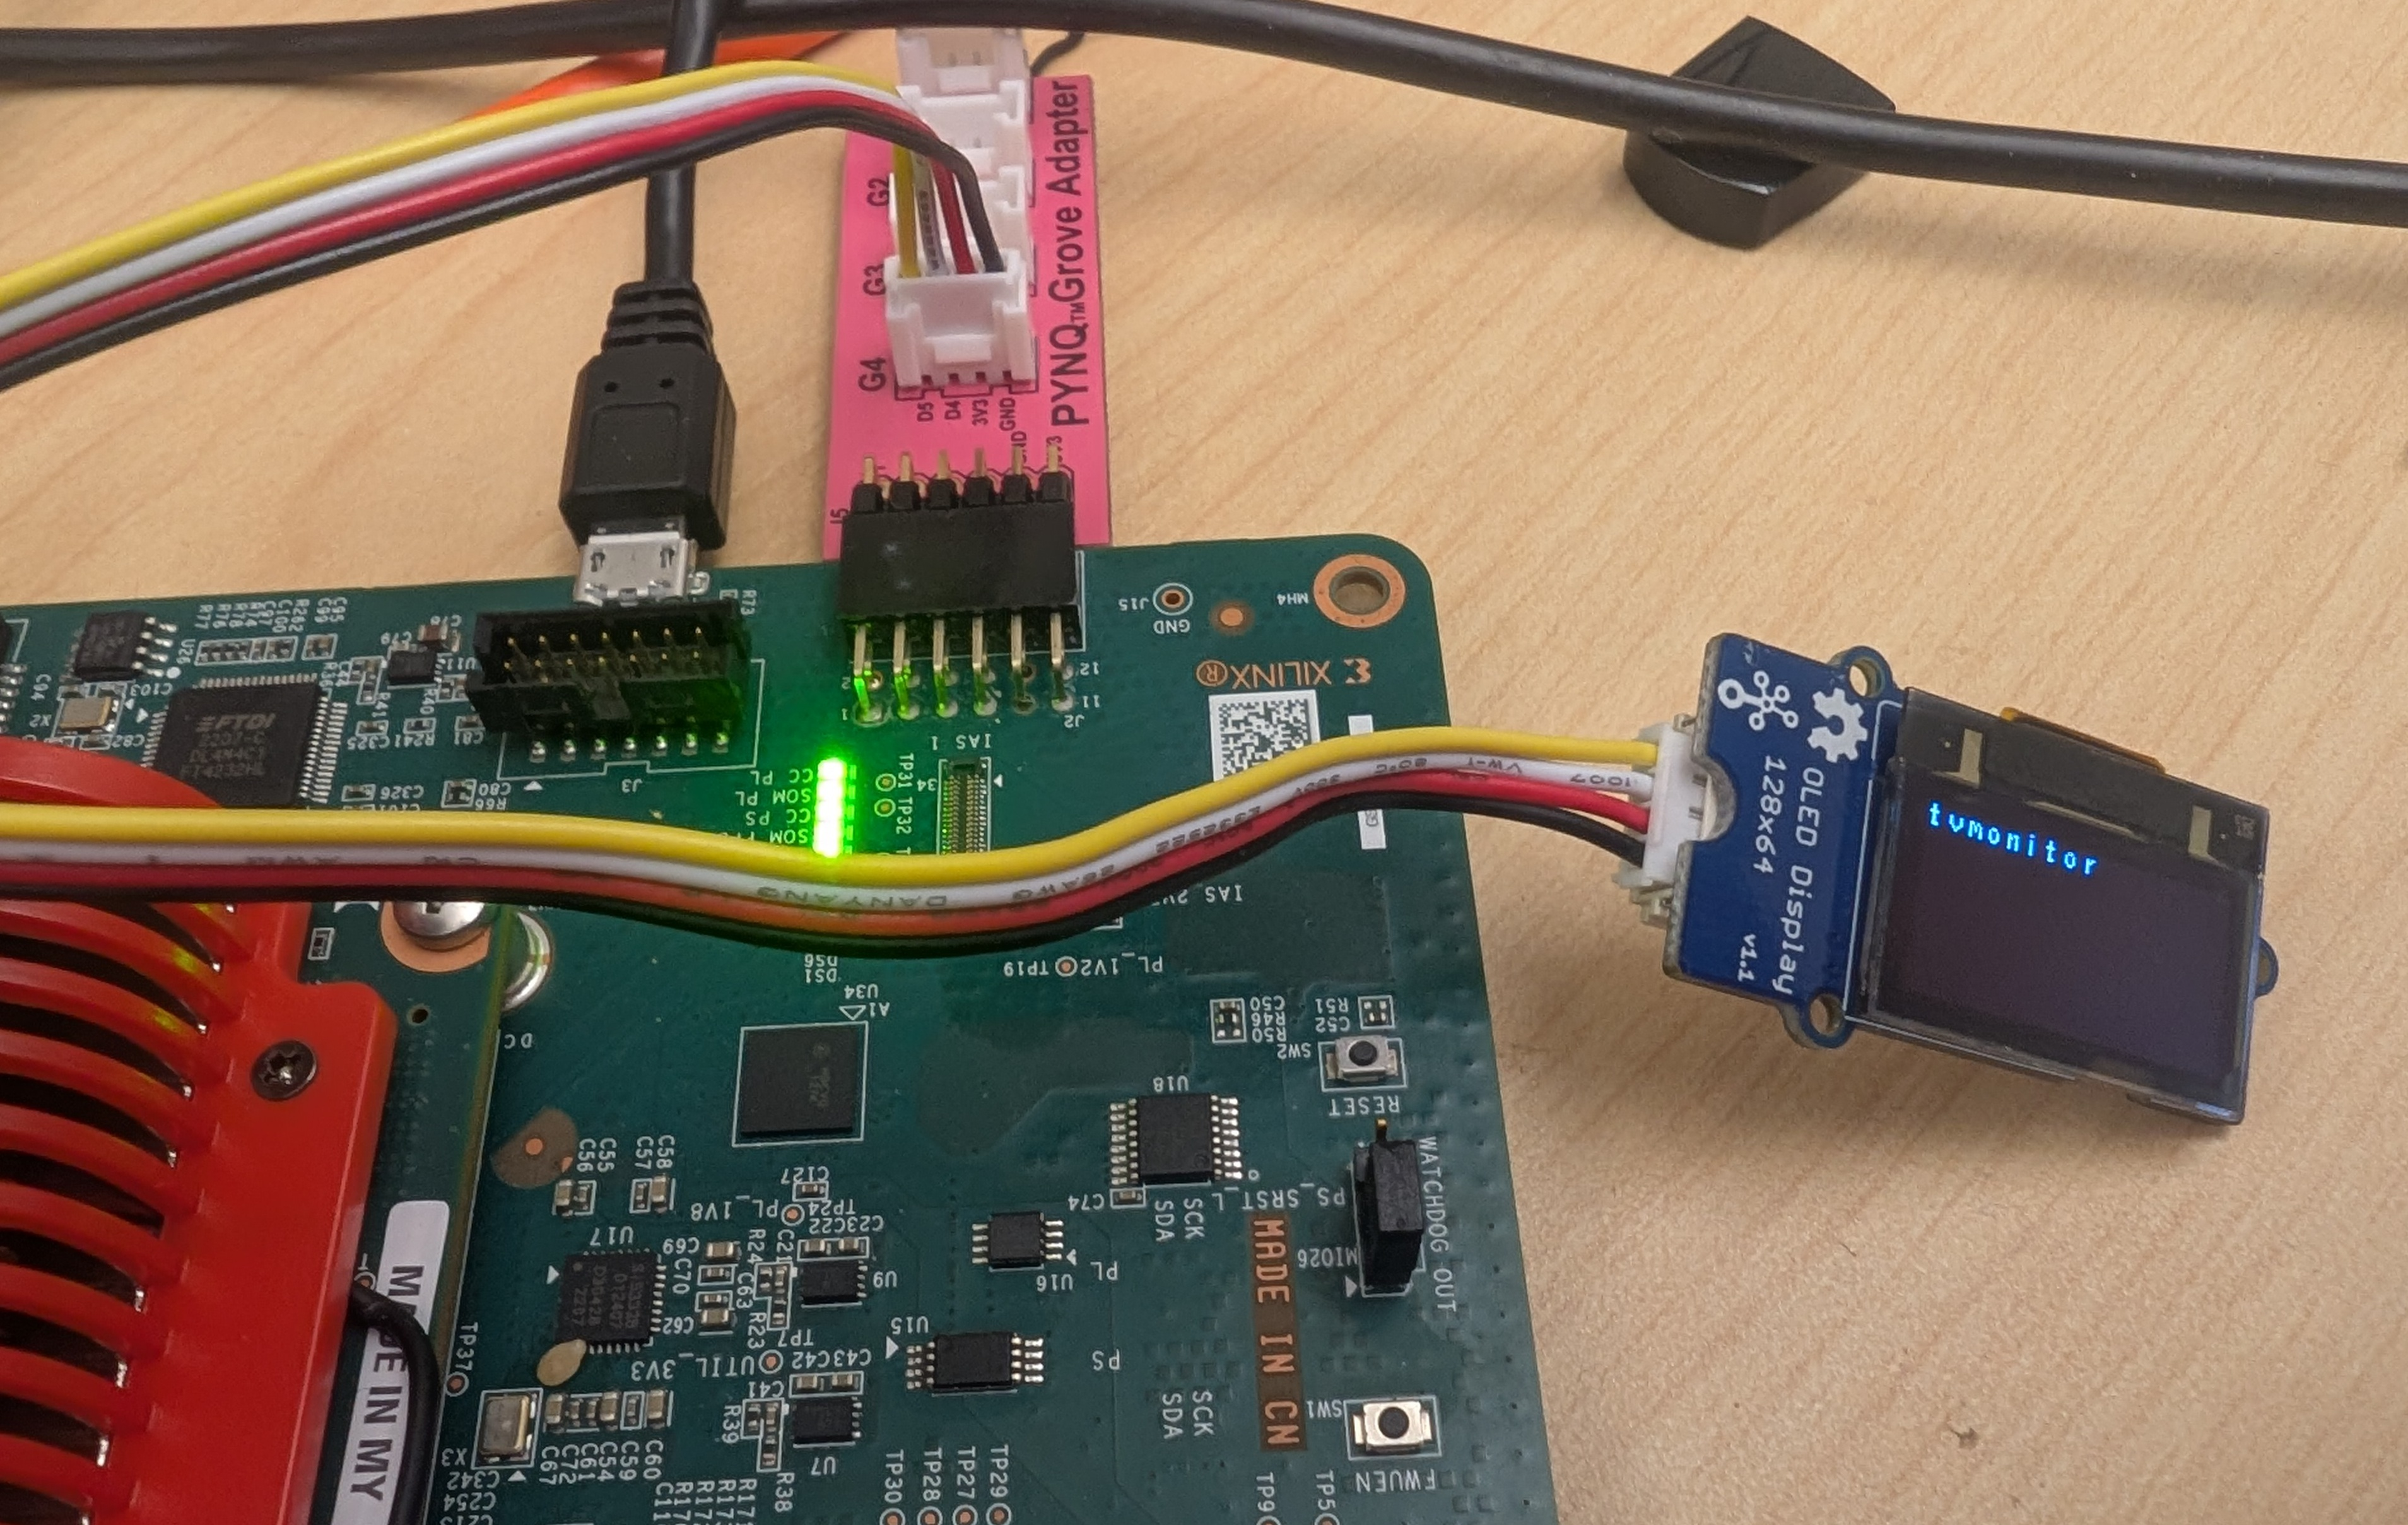


<div style="background: linear-gradient(135deg, #b71c1c 0%, #e65100 100%); border-radius: 16px; padding: 24px 28px; margin: 8px 0 20px 0; box-shadow: 0 4px 18px rgba(183,28,28,0.3);">
<h2 style="color: white; margin: 0 0 6px 0; font-size: 1.6em;">🏁 Challenges — Your Turn!</h2>
<p style="color: rgba(255,255,255,0.9); margin: 0; font-size: 1em;">Modify the live detection loop from Step 5.</p>
</div>

<div style="background: #e3f2fd; border: 2px solid #1565c0; border-radius: 12px; padding: 20px 24px; margin: 16px 0;">
<div style="display: flex; align-items: center; gap: 12px; margin-bottom: 14px;">
<span style="background: #1565c0; color: white; padding: 5px 16px; border-radius: 20px; font-size: 0.85em; font-weight: bold;">🏫 Middle School</span>
<h3 style="color: #0d47a1; margin: 0;">Challenge 1 — Person Detector</h3>
</div>
<p style="color: #1a237e; margin: 0 0 10px 0;">Modify the live loop so it <strong>only</strong> draws a bounding box when a <strong>person</strong> is detected.</p>
<div style="background: rgba(255,255,255,0.7); border-radius: 8px; padding: 10px 14px;">
<strong style="color: #1565c0;">💡 Hint:</strong> <code>class_names.index("person")</code> gives you the class number. Check <code>classes[i]</code> inside the loop.
</div>
</div>

<div style="background: #f3e5f5; border: 2px solid #6a1b9a; border-radius: 12px; padding: 20px 24px; margin: 16px 0;">
<div style="display: flex; align-items: center; gap: 12px; margin-bottom: 14px;">
<span style="background: #6a1b9a; color: white; padding: 5px 16px; border-radius: 20px; font-size: 0.85em; font-weight: bold;">🎓 High School</span>
<h3 style="color: #4a148c; margin: 0;">Challenge 2 — Object Counter</h3>
</div>
<p style="color: #4a148c; margin: 0 0 10px 0;">Track how many frames each class was detected in, then print a summary when the camera stops.</p>
<div style="background: #e8d5f5; border-radius: 8px; padding: 12px 16px; margin: 10px 0; font-family: monospace; font-size: 0.9em; color: #4a148c;">
Session summary:<br>
&nbsp;&nbsp;person &nbsp;&nbsp; — detected in 42 frames<br>
&nbsp;&nbsp;chair &nbsp;&nbsp;&nbsp; — detected in 18 frames
</div>
<div style="background: rgba(255,255,255,0.7); border-radius: 8px; padding: 10px 14px;">
<strong style="color: #6a1b9a;">💡 Hint:</strong> Use a <code>dict</code> to map class names to frame counts. Increment inside the detection loop, print after <code>cap.release()</code>.
</div>
</div>

<div style="background: linear-gradient(135deg, #fff3e0 0%, #fbe9e7 100%); border: 2px solid #e65100; border-radius: 12px; padding: 20px 24px; margin: 16px 0;">
<div style="display: flex; align-items: center; gap: 12px; margin-bottom: 14px;">
<span style="background: linear-gradient(90deg, #e65100, #ff6f00); color: white; padding: 5px 16px; border-radius: 20px; font-size: 0.85em; font-weight: bold;">🌟 Bonus</span>
<h3 style="color: #bf360c; margin: 0;">Build Your Own Filter</h3>
</div>
<p style="color: #bf360c; margin: 0 0 12px 0;">Design a <strong>custom detection filter</strong> with at least two rules of your choice. Be creative!</p>
<ul style="color: #bf360c; line-height: 1.9; margin: 0;">
<li>Only detect animals: <code>dog, cat, bird, horse, sheep, cow</code></li>
<li>Flash the frame border <span style="color: red; font-weight: bold;">red</span> when a car is detected</li>
<li>Count people in frame and show the count on the OLED</li>
</ul>
<p style="color: #bf360c; margin: 10px 0 0 0; font-size: 0.9em;">The full VOC class list is in <code>img/voc_classes.txt</code></p>
</div>


<details style="margin:6px 0 4px 0;border:1px solid #30363d;border-radius:8px;overflow:hidden;">
<summary style="cursor:pointer;background:#161b22;color:#58a6ff;padding:9px 14px;font-size:0.9em;font-family:sans-serif;list-style:none;user-select:none;border-bottom:1px solid #30363d;"><strong>🏁 Challenge starter code</strong> — click to peek, then write your solution in the cell below</summary>
<div style="padding:4px 0 2px 0;"><pre style="background:#1e1e2e;color:#cdd6f4;border-radius:8px;padding:14px 18px;font-family:monospace;font-size:0.88em;line-height:1.6;overflow-x:auto;white-space:pre;margin:10px 0 6px 0;"><code>import ipywidgets as widgets
import threading
from IPython.display import display as ipy_display

PERSON_CLASS = class_names.index(&quot;person&quot;)  # Challenge 1

stop_btn = widgets.ToggleButton(
    value=False, description=&quot;Stop Camera&quot;, button_style=&quot;danger&quot;, icon=&quot;stop&quot;,
    layout=widgets.Layout(width=&quot;150px&quot;, height=&quot;40px&quot;)
)

def my_detection(stop_button):
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    display_handle = ipy_display(None, display_id=True)
    frame_counts = {}  # Challenge 2: tracks per-class frame counts

    while not stop_button.value:
        ret, live_frame = cap.read()
        if not ret:
            break

        boxes, scores, classes = run(live_frame)

        for i, bbox in enumerate(boxes):
            # Challenge 1: only draw when class is PERSON_CLASS
            # Challenge 2: increment frame_counts[class_names[classes[i]]]
            y_min, x_min, y_max, x_max = map(int, bbox)
            class_idx = classes[i]
            color_bgr = colors[class_idx]
            label = &quot;{}: {:.0f}%&quot;.format(class_names[class_idx], scores[i] * 100)
            cv2.rectangle(live_frame, (x_min, y_min), (x_max, y_max), color_bgr, 2)
            cv2.putText(live_frame, label, (x_min, max(y_min - 8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_bgr, 2, cv2.LINE_AA)

        _, encoded = cv2.imencode(&quot;.jpeg&quot;, live_frame)
        display_handle.update(Image(data=encoded.tobytes()))

    cap.release()
    display_handle.update(None)
    # Challenge 2: print summary after camera stops
    # for name, count in sorted(frame_counts.items(), key=lambda x: -x[1]):
    #     print(f&quot;  {name:15s} — detected in {count} frames&quot;)

ipy_display(stop_btn)
threading.Thread(target=my_detection, args=(stop_btn,)).start()</code></pre></div>
</details>


In [ ]:
# Your challenge solution goes here.
# Use the starter code in the peek block above as your starting point.


<div style="background: #eceff1; border-left: 6px solid #607d8b; border-radius: 8px; padding: 16px 20px; margin: 8px 0;">
<strong style="color: #37474f;">🧹 Cleanup</strong><br>
<span style="color: #546e7a; line-height: 1.8;">Run this cell when you are <strong>completely done</strong> with the notebook to release the DPU and FPGA overlay resources so other notebooks can use them.</span>
</div>

In [ ]:
del overlay  # Releases DPU and FPGA overlay resources

In [ ]:
# End of Notebook